### Lasso  Regression

$$
L=\sum_{i=1}^{n}(y_i-\hat{y_i})^2 +\lambda||w||
$$

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt


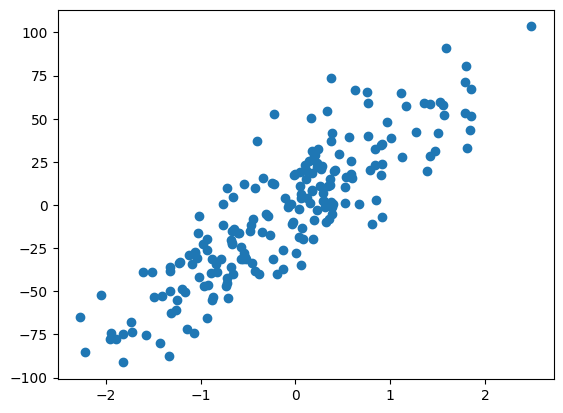

In [11]:
from sklearn.datasets import make_regression
X,y = make_regression(n_samples=200,n_features=1,noise=20)
plt.scatter(X,y)
plt.show()


In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.25)

/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.579e+04, tolerance: 2.204e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model

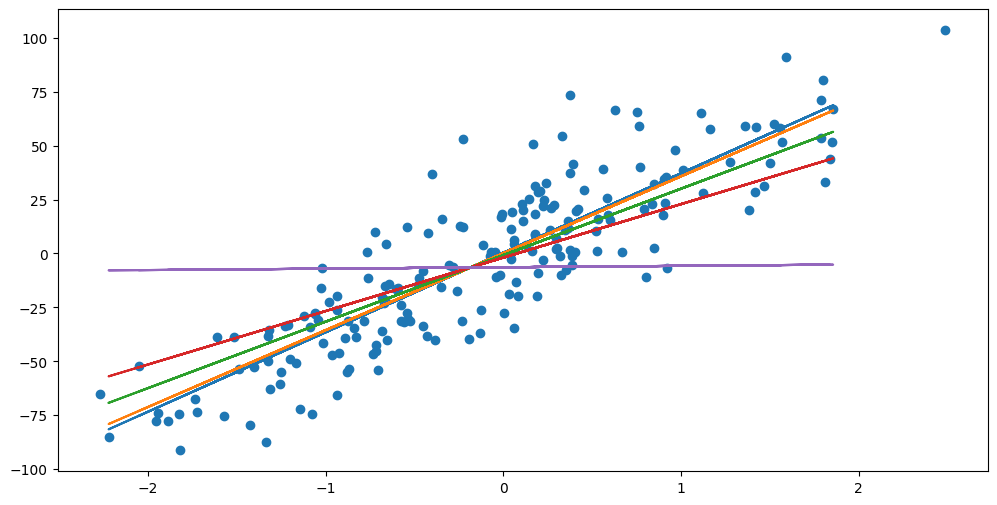

In [ ]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test,L.predict(X_test))

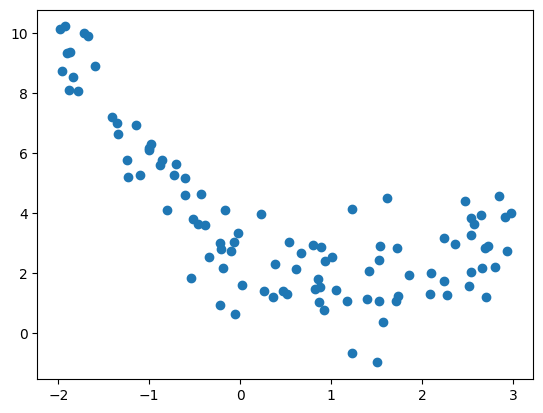

In [14]:
m = 100
X1 = 5*np.random.rand(m,1)-2
X2 = 0.7*X1**2 - 2*X1 + 3 + np.random.randn(m,1)
plt.scatter(X1,X2)
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
def get_pred_lasso(X1,X2,alpha):
    model = Pipeline([
        ('poly_feature',PolynomialFeatures(degree=16)),
        ('lasso',Lasso(alpha=alpha))
    ])
    model.fit(X1,X2)
    return model.predict(X1)



### When we are using the using the lasso regression for very large value of lamdba then the corresponding coefficeint becomes less important so this is also served as the Feature selection and it turns its value as 0 so this is used as the feature selection

### How the coeffiecent are affected

In [15]:
from sklearn.datasets import load_diabetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


In [19]:
data = load_diabetes()


In [20]:
print(type(data))


<class 'sklearn.utils._bunch.Bunch'>


In [21]:
df= pd.DataFrame(data.data,columns=data.feature_names)

In [22]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.25,random_state=42)



In [39]:
coefss = []
scores =[]

for i in [0,0.1,1,10]:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)
    
    coefss.append(reg.coef_)
    y_pred = reg.predict(X_test)
    print(type(y_pred))
    print(type(y_test))
    x = r2_score(y_test,y_pred)
    print(len(x))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.812e+05, tolerance: 2.001e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model

TypeError: 'list' object is not callable

IndexError: list index out of range

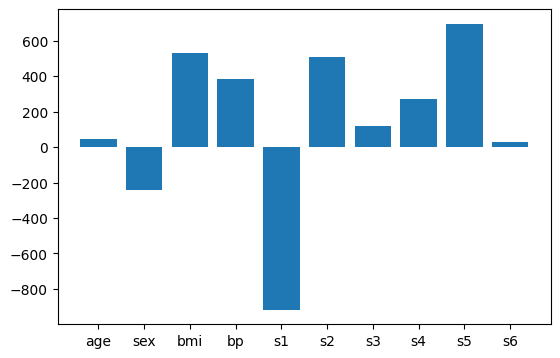

In [30]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 0.1 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 1 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()



## Maths behind the Lasso Regressoion

$$
b=\bar{y}-m\bar{x}\\
L = \sum_{i=1}^{n}(y_i-\hat{y_i})^2 +\lambda|m|\\
\text{there  are two possibilities of m that is m>0 and m<0}
$$

### Case 1 m>0
$$
L =  \sum(y_i-mx_i-b) +\lambda|m|\\
\text{replacing the value of b}\\
L =  \sum(y_i-mx_i-\bar{y}+m\bar{x})^2 +\lambda|m|\\
\frac{dL}{dm} =\sum2(y_i-mx_i-\bar{y}+m\bar{x})(-x_i+\bar{x}) +  \lambda = 0\\
\frac{dL}{dm} = -2\sum(y_i-\bar{y}-m(x_i-\bar{x}))(x_i-\bar{x}) + \lambda\\
\frac{dL}{dm} = -\sum(y_i-\bar{y}-m(x_i-\bar{x}))(x_i-\bar{x}) +  \frac{\lambda}{2}\\
-\sum((y_i-\bar{y})(x_i-\bar{x})-m(x_i-\bar{x})^2)+\frac{\lambda}{2}=0\\

$$
m=\frac{\sum(y_i-\hat{y})(x_i-\hat{x})-\frac{\lambda}{2}}{\sum(x_i-\bar{x})^2}
$$

| **For \(m>0\)** | **For \(m=0\)** | **For \(m<0\)** |
|:---------------:|:---------------:|:---------------:|
| $$m=\frac{\sum (y_i-\bar{y})(x_i-\bar{x})-\lambda}{\sum (x_i-\bar{x})^2}$$ | $$m=\frac{\sum (y_i-\bar{y})(x_i-\bar{x})}{\sum (x_i-\bar{x})^2}$$ | $$m=\frac{\sum (y_i-\bar{y})(x_i-\bar{x})+\lambda}{\sum (x_i-\bar{x})^2}$$ |

### When we will keep increasing the value  of lambda then after some value the value  of m will become negative so the third case will be considerd so the value  will not be nnegative then 

## We use ridge regression when we dont want to remove the contribution of less important fields
## The  Lasso is used to remove the  contribution of less important fields  so it  is used for feature selection


### When we have a large dataset and we are not sure which  one to apply then we use the Elastic regression in such case

## Elastic  Regressoion

$$
L =  \sum_{i=1}^{n}(y_i-\hat{y_i})^2+a||w||^2+b||w||\\
\lambda=a+b\\
l1ratio = \frac{a}{a+b}\\

$$

## Applying Eastic regression on the dataset

In [40]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import r2_score



In [41]:
X,y = load_diabetes(return_X_y=True)

In [49]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [50]:
reg =LinearRegression()
reg.fit(X_train,y_train)
out = reg.predict(X_test)
print(r2_score(y_test,out))

0.40435676641988594


In [57]:
reg = Ridge(alpha=0.233)
reg.fit(X_train,y_train)
res = reg.predict(X_test)
print(r2_score(y_test,res))

0.4209847731804687


In [64]:
reg = Lasso(alpha=0.29)
reg.fit(X_train,y_train)
out = reg.predict(X_test)
print(r2_score(y_test,out))

0.42997589627640176


In [82]:
# ElasticNet
reg = ElasticNet(alpha=0.005,l1_ratio=0.6)
reg.fit(X_train,y_train)
res = reg.predict(X_test)
print(r2_score(y_test,res))

0.40665637840451896


In [83]:
# we can use this using the sklearn SGDRegressor in which we will  use the loss as the elastic